# CatBoost experiment (human vs LLM)

Этот ноутбук повторяет основной эксперимент классификации `human` vs `llm` на табличных метриках и строит графики для главы 3 ВКР.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
HUMAN_CSV = PROJECT_ROOT / "extra" / "dataset_human.csv"
LLM_CSV = PROJECT_ROOT / "extra" / "dataset_llm.csv"
OUT_DIR = PROJECT_ROOT / "extra" / "catboost"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("HUMAN_CSV:", HUMAN_CSV.exists(), HUMAN_CSV)
print("LLM_CSV:", LLM_CSV.exists(), LLM_CSV)

PROJECT_ROOT: /Users/herman/Documents/GitHub/llm-audit-service
HUMAN_CSV: True /Users/herman/Documents/GitHub/llm-audit-service/extra/dataset_human.csv
LLM_CSV: True /Users/herman/Documents/GitHub/llm-audit-service/extra/dataset_llm.csv


In [3]:
human_df = pd.read_csv(HUMAN_CSV)
llm_df = pd.read_csv(LLM_CSV)

human_df["label"] = 0
human_df["origin"] = "human"
llm_df["label"] = 1
llm_df["origin"] = "llm"

df = pd.concat([human_df, llm_df], ignore_index=True)

print("shape:", df.shape)
print(df["origin"].value_counts())
df.head(3)

shape: (375, 13)
origin
human    208
llm      167
Name: count, dtype: int64


,file_name,unicode,lexical_diversity,burstiness,average_sentence_length,text_entropy,stop_word_ratio,word_length_variation,punctuation_ratio,repetition_score,perplexity,label,origin
0,182648157.txt,0.0,0.448690,5.064447,9.956522,9.511864,0.184741,3.747315,0.036180,0.199665,NaN,0,human
1,182710542.txt,0.0,0.379858,4.365939,11.028571,9.969799,0.187438,3.669798,0.028792,0.163506,NaN,0,human
2,182711674.txt,0.0,0.434899,3.754249,11.761324,10.332473,0.200189,3.496201,0.035256,0.147579,NaN,0,human


In [4]:
drop_cols = {"label", "origin", "file_name", "file", "id", "text", "title"}
feature_cols = [c for c in df.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(df[c])]

X = df[feature_cols].copy()
y = df["label"].astype(int)

print("features:", len(feature_cols))
print(feature_cols)

features: 10
['unicode', 'lexical_diversity', 'burstiness', 'average_sentence_length', 'text_entropy', 'stop_word_ratio', 'word_length_variation', 'punctuation_ratio', 'repetition_score', 'perplexity']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=RANDOM_STATE,
    auto_class_weights="Balanced",
    verbose=False,
)

model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_proba)
report = classification_report(y_test, y_pred, target_names=["human", "llm"], output_dict=True)
cm = confusion_matrix(y_test, y_pred)

print(f"ROC-AUC: {auc:.4f}")
pd.DataFrame(report).T

ROC-AUC: 0.9886


,precision,recall,f1-score,support
human,0.945455,1.000000,0.971963,52.000000
llm,1.000000,0.928571,0.962963,42.000000
accuracy,0.968085,0.968085,0.968085,0.968085
macro avg,0.972727,0.964286,0.967463,94.000000
weighted avg,0.969826,0.968085,0.967941,94.000000


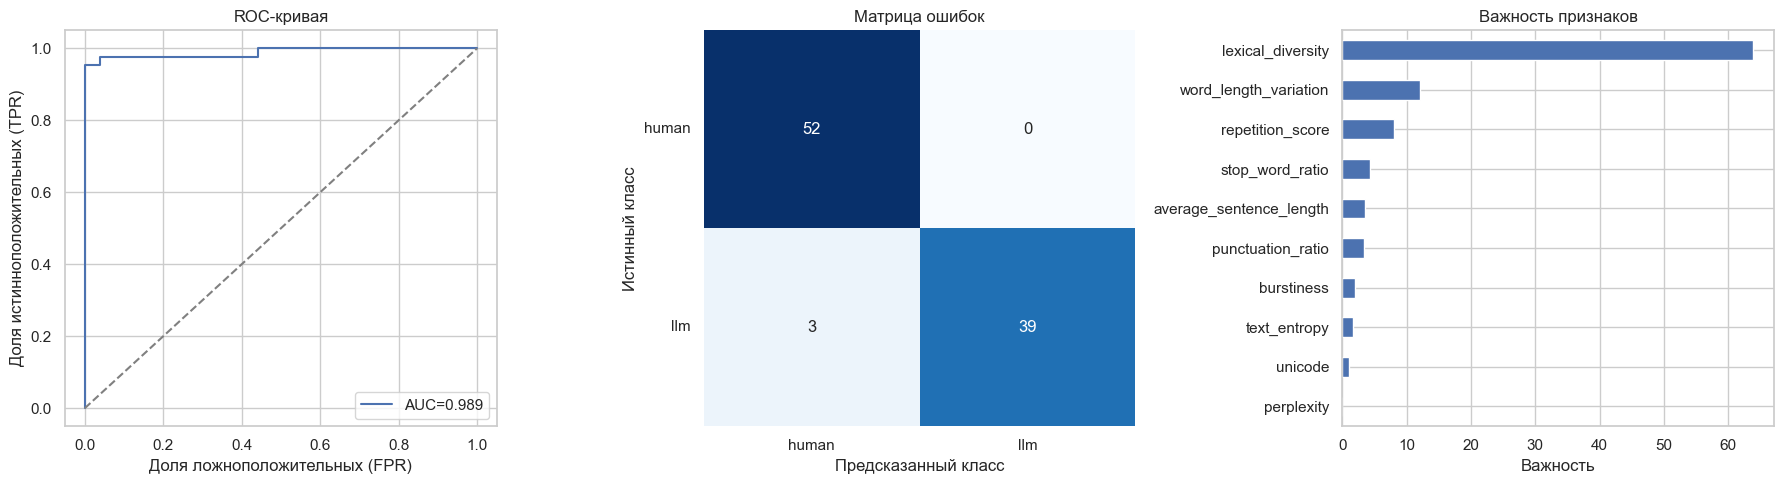

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f"AUC={auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC-кривая")
axes[0].set_xlabel("Доля ложноположительных (FPR)")
axes[0].set_ylabel("Доля истинноположительных (TPR)")
axes[0].legend(loc="lower right")

# Confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Матрица ошибок")
axes[1].set_xlabel("Предсказанный класс")
axes[1].set_ylabel("Истинный класс")
axes[1].set_xticklabels(["human", "llm"])
axes[1].set_yticklabels(["human", "llm"], rotation=0)

# Feature importance
fi = pd.Series(model.get_feature_importance(), index=feature_cols).sort_values(ascending=False).head(12)
fi.sort_values().plot(kind="barh", ax=axes[2])
axes[2].set_title("Важность признаков")
axes[2].set_xlabel("Важность")

plt.tight_layout()
plt.show()

In [7]:
metrics_payload = {
    "test_size": 0.25,
    "random_state": RANDOM_STATE,
    "n_rows": int(len(df)),
    "n_features": int(len(feature_cols)),
    "feature_names": feature_cols,
    "roc_auc": float(auc),
    "classification_report": report,
    "confusion_matrix": cm.tolist(),
}

(OUT_DIR / "metrics_notebook.json").write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2), encoding="utf-8")
model.save_model(str(OUT_DIR / "model_notebook.cbm"))

print("Saved:")
print(" -", OUT_DIR / "metrics_notebook.json")
print(" -", OUT_DIR / "model_notebook.cbm")

Saved:
 - /Users/herman/Documents/GitHub/llm-audit-service/extra/catboost/metrics_notebook.json
 - /Users/herman/Documents/GitHub/llm-audit-service/extra/catboost/model_notebook.cbm
